# About This Project

This notebook builds a binary classification model to predict
whether a breast tumor is malignant or benign using the
Breast Cancer Wisconsin dataset from Scikit-Learn.

<br>

**Dataset:** 569 samples, 30 numerical features, 2 target classes
**Algorithm:** k-Nearest Neighbors (k-NN)


**Key Metric:** Recall on the malignant class — because missing
a malignant tumor carries greater clinical risk than a false alarm

<br>

**Author:** Kevin Carl B. Ricafort

**Date:** June 2026


# Breast Cancer Classification: The Breast Cancer Winsconsin Dataset

*Goal:* Build a machine learning model that predicts whether a tumor is malignant (cancerous) or benign (non-cancerous) based on cell measurement features.


*Dataset:* The Breast Cancer Wisconsin dataset — built directly into Scikit-Learn, no download needed.

<br>

What you will practice:
* Loading a dataset
* Exploratory data analysis
* Preprocessing
* Training a model
* Evaluating results
* Interpreting what the model learned

## Part 1: Load and Explore the Data

In [8]:
# Import the dataset using this exact line:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import matplotlib.pyplot as plt

# Load it with as_frame=True so it comes as a DataFrame
load_df = load_breast_cancer(as_frame = True)
cancer_df = load_df.frame

# Print the shape of the data
print('Shape:' + str(cancer_df.shape))

# Print the first 5 rows
print("\nFirst 5 Rows: ")
print(cancer_df.head())

# Print the feature names
print("\nFeature Names:")
print(load_df.feature_names)

# Print the target names
print("\nTarget Names:")
print(load_df.target_names)

# 5. Check for missing values
print("\nMissing values:")
print(cancer_df.isnull().sum().sum())


# 6. Descriptive statistics
print("\nDescriptive statistics:")
print(cancer_df.describe().round(2))

print(cancer_df.info())

Shape:(569, 31)

First 5 Rows: 
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimet

## Part 2: Understand the Target Variable


In [9]:
# Your tasks for this step:
# 1. Print the value counts of the target column
print(cancer_df['target'].value_counts(sort = True))

# 2. Print the percentage split between the two classes
print(cancer_df['target'].value_counts(normalize = True))

target
1    357
0    212
Name: count, dtype: int64
target
1    0.627417
0    0.372583
Name: proportion, dtype: float64


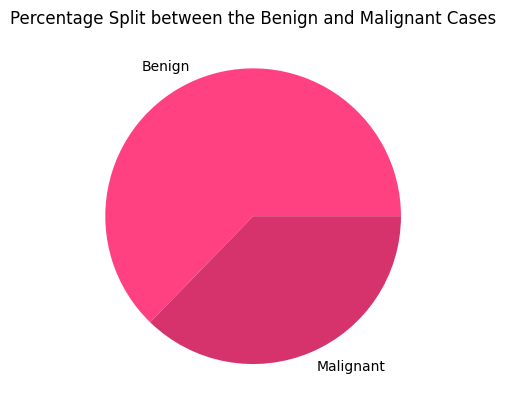

In [10]:
# Visualization of the target variables
pie_label = ['Benign', 'Malignant']

plt.title('Percentage Split between the Benign and Malignant Cases')
plt.pie(cancer_df['target'].value_counts(normalize = True), labels = pie_label, colors = ['#FF4081', '#D6336C'])
plt.show()

*Interpretation:* First, note that the target variables (0, 1) are equivalent to (malignant, benign), respectively. Referring to the counts of the target variables, it shows that there are 357 BENIGN cases and 212 MALIGNANT cases from the dataset, that corresponds to the 62.74 % and 37.2 % population split. Hence, there is an imbalance between the population.

## Part 3: Splitting Data


In [11]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = load_df.data
y = load_df.target

# Split into training and test sets
# stratify ensures that the split subsets maintain the exact same class proportions as the original dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

# Verify the shapes
print("X_train shape:", X_train.shape)  # (455, 30)
print("X_test shape: ", X_test.shape)   # (114, 30)
print("y_train shape:", y_train.shape)  # (455,)
print("y_test shape: ", y_test.shape)   # (114,)

# Verify stratification worked
print("\nTraining class balance:")
print(pd.Series(y_train).value_counts(normalize=True).round(3))

print("\nTest class balance:")
print(pd.Series(y_test).value_counts(normalize=True).round(3))

X_train shape: (455, 30)
X_test shape:  (114, 30)
y_train shape: (455,)
y_test shape:  (114,)

Training class balance:
target
1    0.626
0    0.374
Name: proportion, dtype: float64

Test class balance:
target
1    0.632
0    0.368
Name: proportion, dtype: float64


## Part 4: Scaling Features

In [12]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# fit_transform on training data ONLY
# fit   — learns the mean and std from X_train
# transform — applies the scaling using what it just learned
X_train_scaled = scaler.fit_transform(X_train)

# transform ONLY on test data — never fit_transform
# We apply the SAME mean and std learned from training data
# This is critical — the test set must be scaled using training statistics
X_test_scaled = scaler.transform(X_test)

col_index = 0  # First feature column

print("BEFORE scaling:")
print(f"  Mean : {X_train.iloc[:, col_index].mean():.4f}")
print(f"  Std  : {X_train.iloc[:, col_index].std():.4f}")

print("\nAFTER scaling:")
print(f"  Mean : {X_train_scaled[:, col_index].mean():.4f}")
print(f"  Std  : {X_train_scaled[:, col_index].std():.4f}")


BEFORE scaling:
  Mean : 14.0672
  Std  : 3.4994

AFTER scaling:
  Mean : -0.0000
  Std  : 1.0000


## Part 5: Training the Model

In [17]:

# Import KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier

# Instatiation - Create a model with n_neighbors=8
knn = KNeighborsClassifier(n_neighbors=8)

# Train it on the SCALED training data
knn.fit(X_train_scaled, y_train)

# Make predictions on the SCALED test data
y_pred = knn.predict(X_test_scaled)

# Print the first 10 predictions
print(y_pred[:10])

# Print the first 10 actual values
print(y_test[:10].values)

# Do they match?

[0 1 0 1 0 1 1 0 0 0]
[0 1 0 1 0 1 1 0 0 0]


## Part 6: Evaluate Your Model

In [18]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy Score
print("\nAccuracy Score:")
print(accuracy_score(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['malignant', 'benign']))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy Score:
0.9736842105263158

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        42
      benign       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


Confusion Matrix:
[[40  2]
 [ 1 71]]


*Conclusion: *After the training and testing, the accuuracy score resulted approximately 95.61 percent using a random_state of 42. In addition, the benign class has a recall of of 0.97. It shows that 97 percent of the predicted samples is true. Referring to the confusion matrix, since the False Positive count is 3, hence the number of missed malignant tumors is 3.

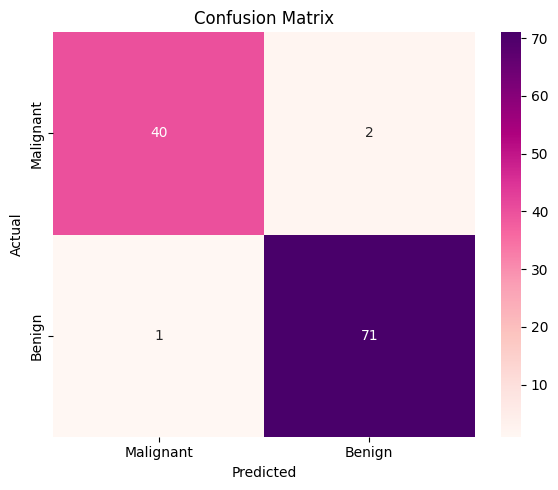

In [28]:
# Replace or supplement your printed confusion matrix with this
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

## Part 7: Find the Best k

In [16]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

k_values = range(1, 21)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

for k, score in zip(k_values, cv_scores):
    print(f"k = {k:2d}  |  CV Accuracy = {score:.4f}")

# Find the best k
best_k = k_values[cv_scores.index(max(cv_scores))]
print(f"\nBest k        : {best_k}")
print(f"Best CV Score : {max(cv_scores):.4f}")

# Retrain model using the best k
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train_scaled, y_train)
y_pred_best = best_knn.predict(X_test_scaled)

print(f"\nNew Accuracy with best k : {accuracy_score(y_test, y_pred_best):.4f}")

k =  1  |  CV Accuracy = 0.9451
k =  2  |  CV Accuracy = 0.9516
k =  3  |  CV Accuracy = 0.9692
k =  4  |  CV Accuracy = 0.9670
k =  5  |  CV Accuracy = 0.9670
k =  6  |  CV Accuracy = 0.9692
k =  7  |  CV Accuracy = 0.9692
k =  8  |  CV Accuracy = 0.9714
k =  9  |  CV Accuracy = 0.9692
k = 10  |  CV Accuracy = 0.9648
k = 11  |  CV Accuracy = 0.9626
k = 12  |  CV Accuracy = 0.9670
k = 13  |  CV Accuracy = 0.9582
k = 14  |  CV Accuracy = 0.9648
k = 15  |  CV Accuracy = 0.9604
k = 16  |  CV Accuracy = 0.9604
k = 17  |  CV Accuracy = 0.9582
k = 18  |  CV Accuracy = 0.9582
k = 19  |  CV Accuracy = 0.9582
k = 20  |  CV Accuracy = 0.9604

Best k        : 8
Best CV Score : 0.9714

New Accuracy with best k : 0.9737


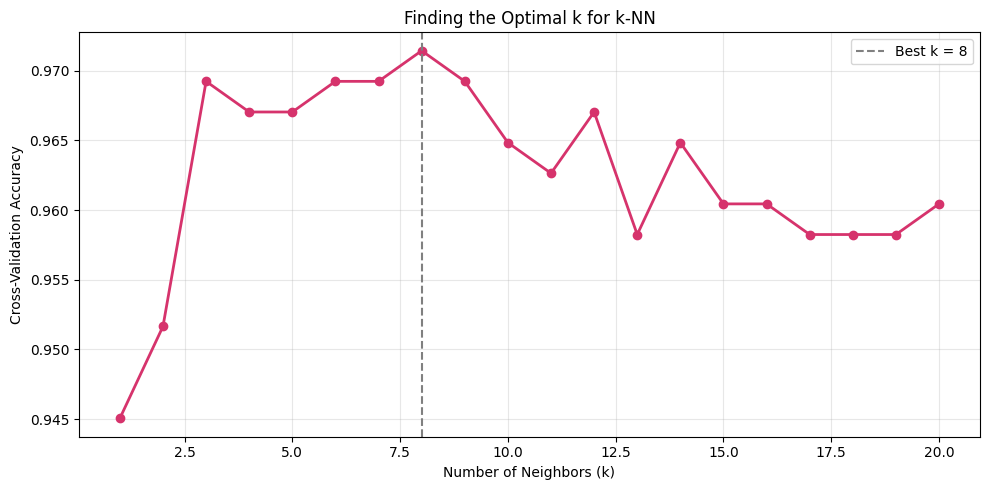

In [27]:
# Part 7 Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(k_values, cv_scores, marker='o', linewidth=2,
         color='#D6336C', markersize=6)
plt.axvline(x=best_k, color='gray', linestyle='--',
            label=f'Best k = {best_k}')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Cross-Validation Accuracy')
plt.title('Finding the Optimal k for k-NN')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Part 8: Building a Pipeline


In [20]:
from sklearn.pipeline import Pipeline

# Rebuild your entire workflow as a single Pipeline object
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=8))
])

# Train and evaluate the pipeline
pipeline.fit(X_train, y_train)
y_pred_pipeline = pipeline.predict(X_test)

print("Pipeline Accuracy:")
print(accuracy_score(y_test, y_pred_pipeline))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_pipeline, target_names=['malignant', 'benign']))


Pipeline Accuracy:
0.9736842105263158

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        42
      benign       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



## Part 9: Predict for a New Patient

In [26]:
import numpy as np

# New patient data
new_patient = np.array([[17.99, 10.38, 122.8, 1001.0, 0.1184, 0.2776,
                          0.3001, 0.1471, 0.2419, 0.07871, 1.095, 0.9053,
                          8.589, 153.4, 0.006399, 0.04904, 0.05373, 0.01587,
                          0.03003, 0.006193, 25.38, 17.33, 184.6, 2019.0,
                          0.1622, 0.6656, 0.7119, 0.2654, 0.4601, 0.1189]])

# Store the prediction and probabilities
prediction  = pipeline.predict(new_patient)
probability = pipeline.predict_proba(new_patient)

# Get the class name and confidence
# 0 means we are checking if it is malignant
predicted_class = load_df.target_names[prediction[0]]
confidence      = probability[0][prediction[0]] * 100

# Print the result
print(f"Prediction  : {predicted_class.capitalize()}")
print(f"Confidence  : {confidence:.2f}%")

# Advisory message
if predicted_class == 'malignant':
    print("Advice      : Recommend immediate further testing")
else:
    print("Advice      : No immediate concern, routine monitoring advised")

Prediction  : Malignant
Confidence  : 100.00%
Advice      : Recommend immediate further testing


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
